# Anomaly detection using residuals

In this example we are using airline passengers data here: https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

Time series can be thought of as containing three components: 
1. Trend $(t_t)$: the general shape of the data over time
2. Seasonality $(s_t)$: Patterns based on time
3. Noise $(\epsilon_t)$: Random noise assumed to be normally distributed

Time series can be additive:

$x_t = t_t+s_t+\epsilon_t$

Or multiplicative:

$x_t = t_ts_t\epsilon_t$

For this example, we assume that the time series is additive. We use statsmodels seasonal decompose to break the time series into trend, seasonality, and residuals (noise). We can use the assumption that the residuals are normally distributed to identify anomalies. Here we use a simple rule of thumb: anything outside of 3 standard deviations of the mean is an outlier.

For more on statsmodels seasonal decompose: https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
dataset = pd.read_csv(url, index_col='Month', parse_dates=True)

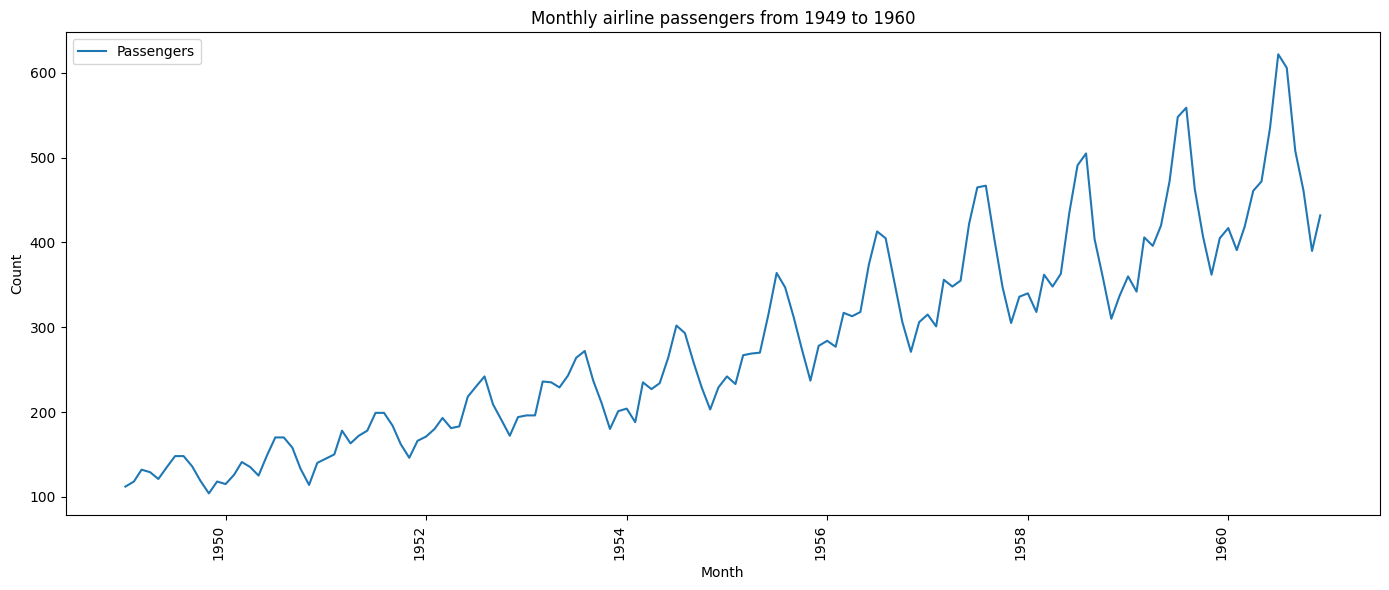

In [3]:
# plot data
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(dataset, label = "Passengers")
plt.legend()
plt.title(f'Monthly airline passengers from 1949 to 1960')
plt.xlabel("Month")
plt.ylabel('Count')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

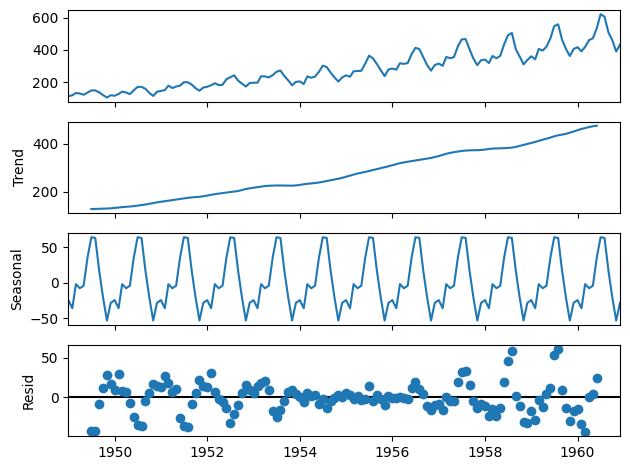

In [4]:
result = seasonal_decompose(dataset, model='additive', period=12)
result.plot()
plt.show()

In [5]:
residuals_df = pd.DataFrame({'Month':list(dataset.index), 'residuals': list(result.resid)}).dropna()
mean_residual = residuals_df['residuals'].mean()
std_residual = residuals_df['residuals'].std()

print(f"Mean Residuals: {mean_residual}")
print(f"Standard Deviation of Residuals: {std_residual}")

Mean Residuals: -0.7512626262626092
Standard Deviation of Residuals: 19.340534782212284


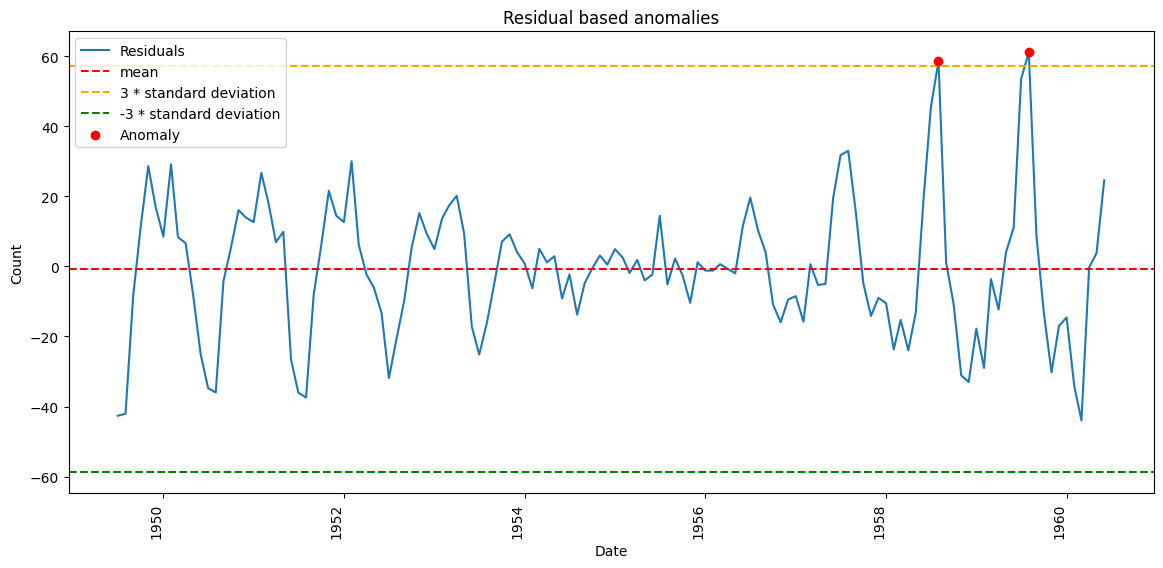

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(residuals_df['Month'], residuals_df['residuals'], label = "Residuals")
plt.axhline(y=mean_residual, color='r', linestyle='--', label = "mean")
plt.axhline(y=mean_residual+3*std_residual, color='orange', linestyle='--', label = "3 * standard deviation")
plt.axhline(y=mean_residual-3*std_residual, color='green', linestyle='--', label = "-3 * standard deviation")
outliers = ((residuals_df['residuals']<-3*std_residual)|(residuals_df['residuals']>3*std_residual))
plt.scatter(
    residuals_df.loc[outliers, 'Month'],
    residuals_df.loc[outliers, 'residuals'],
    color = 'red', label = 'Anomaly', zorder = 5
)
plt.xticks(rotation = 90, ha = 'right')
plt.title(f'Residual based anomalies')
plt.xlabel("Date")
plt.ylabel('Count')
plt.legend()
plt.show()

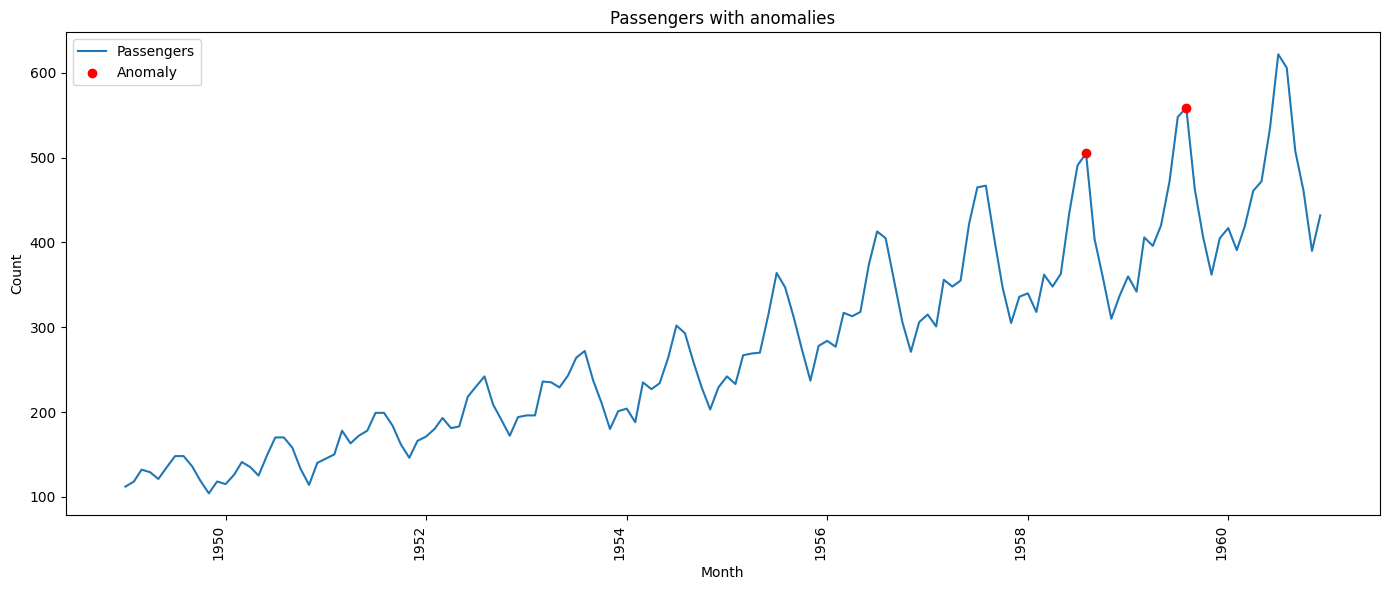

In [7]:
# plot data
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(dataset, label = "Passengers")
outlier_index = residuals_df.loc[outliers].index
plt.scatter(
    dataset.iloc[outlier_index].index,
    dataset.iloc[outlier_index]['Passengers'],
    color = 'red', label = 'Anomaly', zorder = 5
)
plt.legend()
plt.title(f'Passengers with anomalies')
plt.xlabel("Month")
plt.ylabel('Count')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()